In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

from numerical_approximation.chemotaxis import (
    ArcParams,
    ArcPhiParams,
    Endpoint,
    ExternalBC,
    InternalNode,
    arc_mass,
    step_network,
)

In [2]:
n_edges = 3
n_nodes = 4 # Not coupling these for now

kappa = np.ones((n_edges,n_edges))
np.fill_diagonal(kappa, 0)

# Each edge has its own parameter set
D = [1 for _ in range(n_edges)]
a = [1 for _ in range(n_edges)]
b = [0.1 for _ in range(n_edges)]

Outer boundary conditions for $\phi$ to mimic the presence of food at the left and lower ends:
$$
\partial_x \phi_1(0, t) = -1;\; \partial_x \phi_2(L_2, t) = 1
$$

In [3]:
LEFT_TRUNK, RIGHT_TRUNK, STEM = 0, 1, 2

L = 1.0                # length of every arc
lam = math.sqrt(0.33)  # transport speed
chi = 1.0               # chemotactic sensitivity
M = 30                  # interior grid points per arc
h = L / (M + 1)
k = h / (2 * lam)  # CFL: h = 2*k*lam

arc_params = {i: ArcParams(lam=lam, h=h, k=k, chi=chi) for i in range(n_edges)}
phi_arc_params = {i: ArcPhiParams(D=D[i], a=a[i], b=b[i], h=h, k=k, M=M) for i in range(n_edges)}

external_bcs = [
    ExternalBC(Endpoint(LEFT_TRUNK, "left"), kind="flux", phibar=-1.0),   # Eq. (41): phi_x_1(0,t) = -1
    ExternalBC(Endpoint(RIGHT_TRUNK, "right"), kind="flux", phibar=1.0),  # Eq. (41): phi_x_2(L_2,t) = 1
    ExternalBC(Endpoint(STEM, "right"), kind="robin1"),                   # Eq. (42): food-free outer end
]

# kappa is edge-indexed (defined above); the internal node joins one endpoint per arc.
kappa_dict = {(i, j): kappa[i, j] for i in range(n_edges) for j in range(n_edges) if i != j}
internal_node = InternalNode(
    endpoints=[Endpoint(LEFT_TRUNK, "right"), Endpoint(RIGHT_TRUNK, "left"), Endpoint(STEM, "left")],
    kappa=kappa_dict,
)

# The three (arc, side) endpoints that meet at the internal node, for u/v's
# own xi-weighted coupling
NODE_EDGES = [(LEFT_TRUNK, "right"), (RIGHT_TRUNK, "left"), (STEM, "left")]
xi = {(i, j): 1 / 3 for i, _ in NODE_EDGES for j, _ in NODE_EDGES}


BC_TYPE = {
    (LEFT_TRUNK, "left"): "neumann", (LEFT_TRUNK, "right"): "node",
    (RIGHT_TRUNK, "left"): "node", (RIGHT_TRUNK, "right"): "neumann",
    (STEM, "left"): "node", (STEM, "right"): "neumann",
}

In [4]:
T = 20 # total simulated time
n_time_steps = round(T / k) + 1

u_minus = {i: np.zeros((n_time_steps, M + 2)) for i in range(n_edges)}
u_plus = {i: np.zeros((n_time_steps, M + 2)) for i in range(n_edges)}
phi = {i: np.zeros((n_time_steps, M + 2)) for i in range(n_edges)}

# Plasmodium spread ~ U[0.25, 0.35] on each arc; phi(x,0) = 0; v(x,0) = 0
# (i.e. u_minus = u_plus = u/2, at rest) to mimic plasmodium already
# occupying the whole network.
rng = np.random.default_rng()
for i in range(n_edges):
    u0 = rng.uniform(0.25, 0.35, size=M + 2)
    u_minus[i][0, :] = u0 / 2
    u_plus[i][0, :] = u0 / 2

record_every = 5
t_history = []
mass_history = {i: [] for i in range(n_edges)}

for n in range(n_time_steps - 1):
    if n % record_every == 0:
        t_history.append(n * k)
        for i in range(n_edges):
            mass_history[i].append(arc_mass(u_minus[i][n], u_plus[i][n], h))

    step_network(
        u_minus, u_plus, phi, n,
        arc_params, phi_arc_params, BC_TYPE,
        NODE_EDGES, xi, external_bcs, [internal_node],
    )

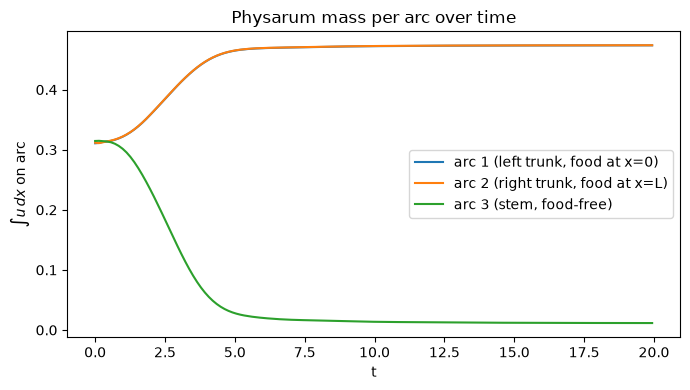

In [5]:
arc_labels = {
    LEFT_TRUNK: "arc 1 (left trunk, food at x=0)",
    RIGHT_TRUNK: "arc 2 (right trunk, food at x=L)",
    STEM: "arc 3 (stem, food-free)",
}

fig, ax = plt.subplots(figsize=(7, 4))
for i in range(n_edges):
    ax.plot(t_history, mass_history[i], label=arc_labels[i])
ax.set_xlabel("t")
ax.set_ylabel(r"$\int u\,dx$ on arc")
ax.set_title("Physarum mass per arc over time")
ax.legend()
plt.tight_layout()
plt.show()

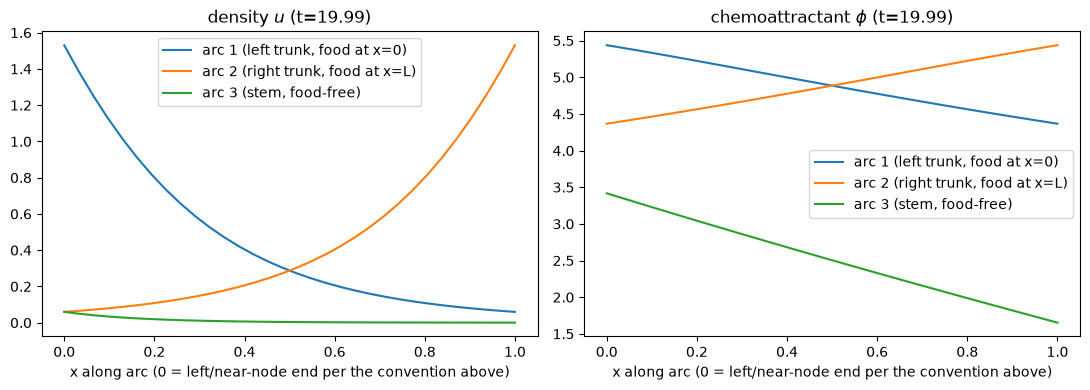

In [6]:
x = np.linspace(0, L, M + 2)

fig, (ax_u, ax_phi) = plt.subplots(1, 2, figsize=(11, 4))
for i in range(n_edges):
    u_final = u_minus[i][-1] + u_plus[i][-1]
    ax_u.plot(x, u_final, label=arc_labels[i])
    ax_phi.plot(x, phi[i][-1], label=arc_labels[i])

ax_u.set_title(f"density $u$ (t={(n_time_steps - 1) * k:.2f})")
ax_phi.set_title(r"chemoattractant $\phi$" + f" (t={(n_time_steps - 1) * k:.2f})")
for axx in (ax_u, ax_phi):
    axx.set_xlabel("x along arc (0 = left/near-node end per the convention above)")
    axx.legend()
plt.tight_layout()
plt.show()

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection


def _arc_positions(
    start: tuple[float, float], end: tuple[float, float], n: int, curvature: float = 0.0
) -> tuple[np.ndarray, np.ndarray]:
    """n points along a straight line (curvature=0) or a quadratic-Bezier bow
    (curvature = perpendicular control-point offset, as a fraction of arc length)."""
    p0, p1 = np.array(start), np.array(end)
    t = np.linspace(0, 1, n)
    if curvature == 0:
        pts = p0 + t[:, None] * (p1 - p0)
        return pts[:, 0], pts[:, 1]

    direction = p1 - p0
    length = np.linalg.norm(direction)
    perp = np.array([-direction[1], direction[0]]) / length if length else np.zeros(2)
    control = (p0 + p1) / 2 + perp * curvature * length
    pts = (
        (1 - t)[:, None] ** 2 * p0
        + 2 * (1 - t)[:, None] * t[:, None] * control
        + t[:, None] ** 2 * p1
    )
    return pts[:, 0], pts[:, 1]


def plot_network_density(
    node_pos: dict[int, tuple[float, float]],
    arcs: dict[int, tuple[int, int]],           # arc_id -> (start_node, end_node)
    u_values: dict[int, np.ndarray],             # arc_id -> density along the arc, j=0..M+1
    *,
    curvature: dict[int, float] | None = None,
    cmap: str = "jet",
    vmin: float | None = None,
    vmax: float | None = None,
    lw_range: tuple[float, float] = (1.5, 8.0),
    title: str | None = None,
    ax: plt.Axes | None = None,
) -> tuple[plt.Figure, plt.Axes]:
    """One frame of the density plot (call once per time step you want to show)."""
    fig, ax = (ax.figure, ax) if ax is not None else plt.subplots()

    if vmin is None or vmax is None:
        all_vals = np.concatenate([np.asarray(v) for v in u_values.values()])
        vmin = float(all_vals.min()) if vmin is None else vmin
        vmax = float(all_vals.max()) if vmax is None else vmax
    norm = plt.Normalize(vmin, vmax)
    lw_min, lw_max = lw_range

    segments, colors, widths = [], [], []
    for arc_id, (n0, n1) in arcs.items():
        u = np.asarray(u_values[arc_id])
        curv = 0.0 if curvature is None else curvature.get(arc_id, 0.0)
        x, y = _arc_positions(node_pos[n0], node_pos[n1], len(u), curv)
        pts = np.column_stack([x, y]).reshape(-1, 1, 2)
        segments.append(np.concatenate([pts[:-1], pts[1:]], axis=1))
        seg_vals = (u[:-1] + u[1:]) / 2
        colors.append(seg_vals)
        widths.append(lw_min + (lw_max - lw_min) * norm(seg_vals))

    lc = LineCollection(
        np.concatenate(segments, axis=0),
        cmap=cmap, norm=norm,
        linewidths=np.concatenate(widths, axis=0),
        capstyle="round",
    )
    lc.set_array(np.concatenate(colors, axis=0))
    ax.add_collection(lc)

    xs, ys = zip(*node_pos.values())
    pad_x = 0.15 * (max(xs) - min(xs) + 1e-9)
    pad_y = 0.15 * (max(ys) - min(ys) + 1e-9)
    ax.set_xlim(min(xs) - pad_x, max(xs) + pad_x)
    ax.set_ylim(min(ys) - pad_y, max(ys) + pad_y)
    ax.set_aspect("equal")
    if title:
        ax.set_title(title)
    fig.colorbar(lc, ax=ax)
    return fig, ax

## Density on the graph itself

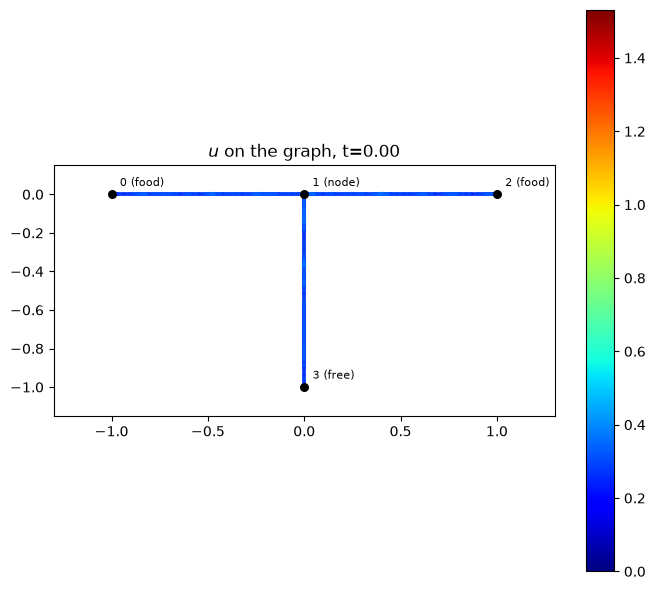

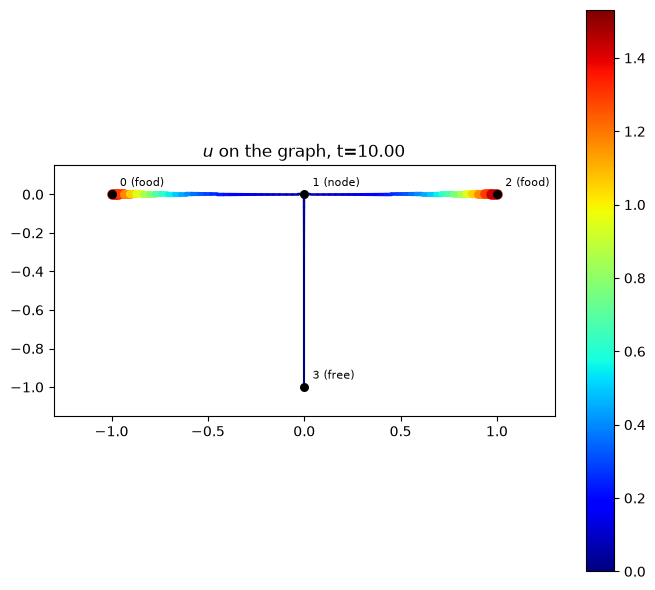

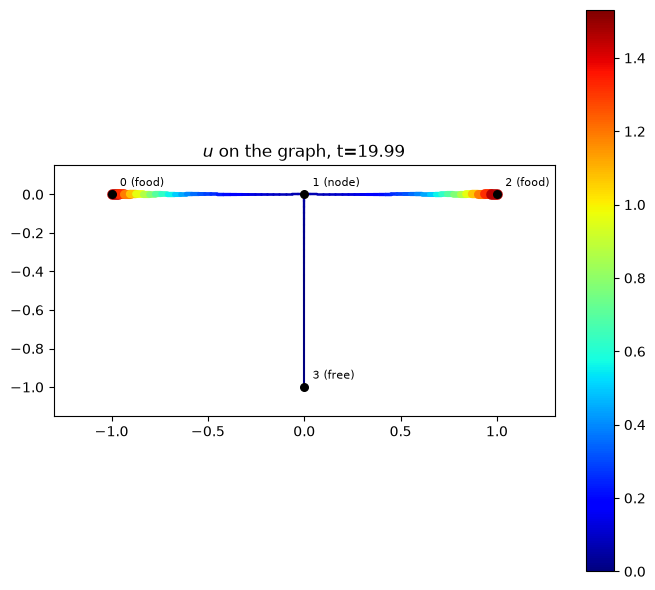

In [8]:
# Node numbering matches the directed edges 0->1 (LEFT_TRUNK), 1->2
# (RIGHT_TRUNK), 1->3 (STEM): each arc's j=0 ("left") is its tail, j=M+1
# ("right") is its head, so u_minus[i]+u_plus[i] is already in start->end
# order and can be passed straight through.
NODE_POS = {0: (-1.0, 0.0), 1: (0.0, 0.0), 2: (1.0, 0.0), 3: (0.0, -1.0)}
ARC_ENDPOINTS = {LEFT_TRUNK: (0, 1), RIGHT_TRUNK: (1, 2), STEM: (1, 3)}
NODE_LABELS = {0: "0 (food)", 1: "1 (node)", 2: "2 (food)", 3: "3 (free)"}

snapshot_indices = sorted({0, (n_time_steps - 1) // 2, n_time_steps - 1})

vmin = 0.0
vmax = max((u_minus[i] + u_plus[i]).max() for i in range(n_edges))

for idx in snapshot_indices:
    u_values = {i: u_minus[i][idx] + u_plus[i][idx] for i in range(n_edges)}
    fig, ax = plt.subplots(figsize=(7, 6))
    plot_network_density(
        NODE_POS, ARC_ENDPOINTS, u_values,
        vmin=vmin, vmax=vmax,
        title=f"$u$ on the graph, t={idx * k:.2f}",
        ax=ax,
    )
    for node, (x, y) in NODE_POS.items():
        ax.scatter([x], [y], s=30, color="black", zorder=3)
        ax.annotate(NODE_LABELS[node], (x, y), textcoords="offset points", xytext=(6, 6), fontsize=8)
    plt.tight_layout()
    plt.show()